In [1]:

from pathlib import Path
from typing import Optional

import openvsp as vsp
from matplotlib import pyplot as plt
import numpy as np
import math
from assignment1.utils.vsp_manager import VspManager, AnalysisSettings


In [2]:
to_get = ['Alpha', 'CLtot', 'CDtot']

vsp_file = Path('wing_assignment.vsp3')
aero_path = Path('~/Downloads/OpenVSP-3.48.1-win64').expanduser()
manager = VspManager(aero_path, vsp_file)

analysis_name = "VSPAEROSweep"
thin_set_analysis = "VSPAEROComputeGeometry"
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=thin_set_analysis, name="GeomSet"), 0)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=thin_set_analysis, name="ThinGeomSet"), -1)
manager.setup_analysis()

'VSPAEROSweep'

## Task 1

Calculate the drag polar,  $C_L$ vs $\alpha$, lift slope and maximum lift coefficient.

I cheated a bit and created this airfoil in a GUI, and then saved as `wing_assignment.vsp3` instead of going through the process of creating the geometry through the API, which is a bit cumbersome and not really the point of this assignment.

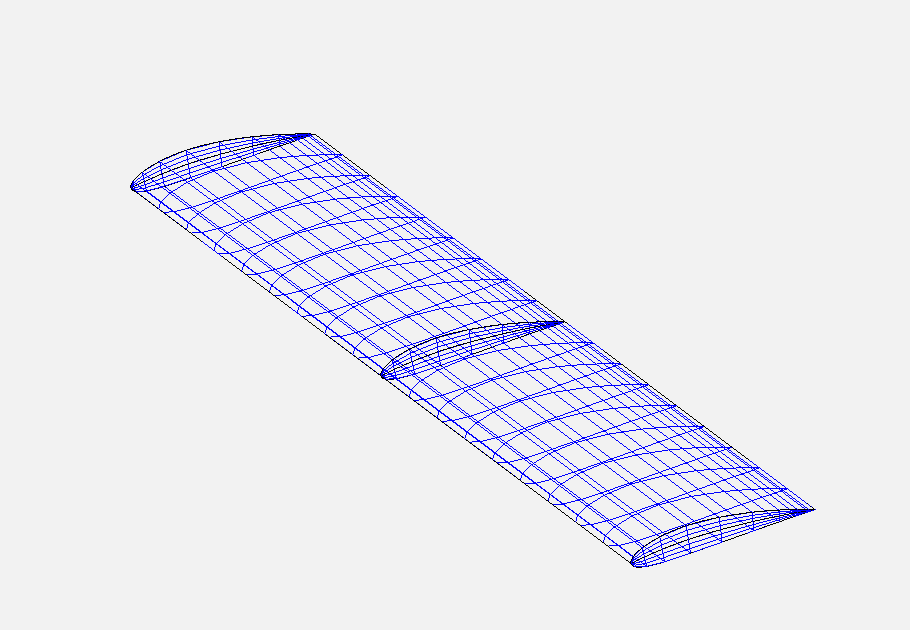

To get a Reynolds number of $3.0 \cdot 10^{6}$ and an AR of 5 the following parameters are used
* Air: standard conditions
* Chord: 1200 (mm)
* Airspeed: 36.939 (m/s)
* Wingspan: 6000 (mm)

The rest of simulation parameters are as follows
* Mach number: 0.108
* 20 panels in chord- and span-wise directions (in code)
* Thick panel method
* The stall model was turned on, with the following parameters, obtained from the NACA report
    * CLMax2D: 1.41
    * Clo2D: 0.073


In [3]:
# Just some utility functions
def get_max_cl(experiment_result: dict[str, list[float]]) -> float:
    return np.max(experiment_result['CLtot'])

def get_alpha_at_max_cl(experiment_result: dict[str, list[float]]) -> float:
    return experiment_result['Alpha'][np.argmax(experiment_result['CLtot'])]

def get_lift_slope(experiment_result: dict[str, list[float]], alpha1: float = -1, alpha2: float = 6) -> float:
    idx1 = np.argmin(np.abs(np.array(experiment_result['Alpha']) - alpha1))
    idx2 = np.argmin(np.abs(np.array(experiment_result['Alpha']) - alpha2))
    return (experiment_result['CLtot'][idx2] - experiment_result['CLtot'][idx1]) / math.radians(experiment_result['Alpha'][idx2] - experiment_result['Alpha'][idx1])

def draw_polars(experiment_results: list[dict[str, list[float]]] | dict[str, list[float]], labels: Optional[list[str]] = None, cl_name: str = 'CLtot', cd_name: str = 'CDtot'):
    if isinstance(experiment_results, dict):
        experiment_results = [experiment_results]

    for i, experiment_result in enumerate(experiment_results):
        label_suffix = f"_{labels[i]}" if labels and len(labels) == len(experiment_results) else ""
        plt.plot(experiment_result['Alpha'], experiment_result[cl_name], label="CL" + label_suffix)
        plt.xlabel("Alpha (deg)")
        plt.ylabel("Lift Coefficient")
        plt.title("CL vs Alpha")
        plt.legend()
        plt.grid()
    plt.show()

    for i, experiment_result in enumerate(experiment_results):
        label_suffix = f"_{labels[i]}" if labels and len(labels) == len(experiment_results) else ""
        plt.plot(experiment_result[cd_name], experiment_result[cl_name], label="CLvsCD" + label_suffix)
        plt.xlabel("Drag Coefficient")
        plt.ylabel("Lift Coefficient")
        plt.title("Drag polar")
        plt.legend()
        plt.grid()
    plt.show()

In [4]:
# And some constants
MIN_U = 5
MIN_W = 5
DEFAULT_U = 20
DEFAULT_W = 20
MAX_U = 60
MAX_W = 60
N_POINTS = 8
MAX_2D_CL = 1.41
EXP_LIFT_SLOPE = 6.0876765733
EXP_STALL_AOA = 10

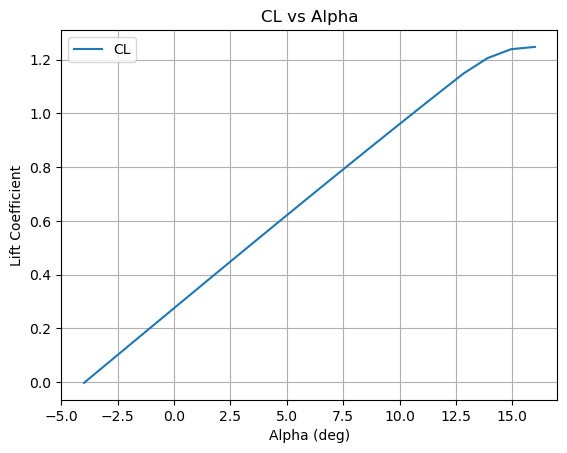

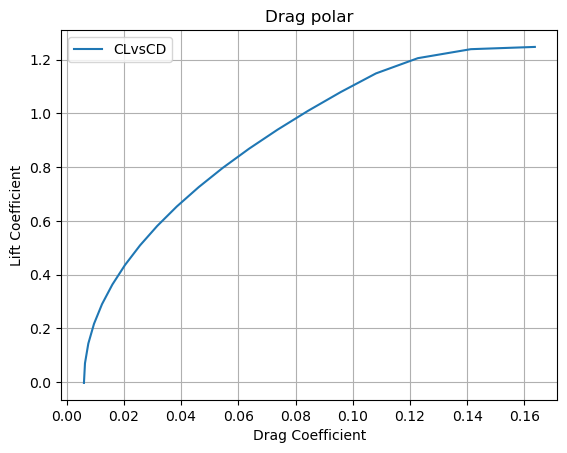

Max CL: 1.246898227391 at Alpha: 16.0
Lift slope: 3.95891469518083
Experimental max 2D Cl: 1.41 at Alpha: 10
Experimental lift slope: 6.0876765733


In [5]:
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="SectTess_U"), DEFAULT_U)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="Tess_W"), DEFAULT_W)
manager.setup_analysis()
data_t1 = manager.perform_analysis(analysis_name, to_get)

draw_polars(data_t1)

print(f"Max CL: {get_max_cl(data_t1)} at Alpha: {get_alpha_at_max_cl(data_t1)}")
print(f"Lift slope: {get_lift_slope(data_t1)}")

print(f"Experimental max 2D Cl: {MAX_2D_CL} at Alpha: {EXP_STALL_AOA}")
print(f"Experimental lift slope: {EXP_LIFT_SLOPE}")


By the visual inspection, the results look good; there is a nice and linear $C_L$ increase up to the near-stall AoA which is accompanied by a sharply increasing drag, which makes sense

The $C_{Lmax}$ and $\frac{\partial C_L}{\partial \alpha}$ are both lower, while the stall AoA is higher than the experimental 2D values because of downwash reducing the effective AoA. This reduction postpones the stall and reduces the lift slope, which is expected for a finite wing.



## Task 2
This one takes quite some time to complete, some 12ish minutes on my machine.

The plan is to first sweep through chordwise panel counts, then, through the spanwise counts, and then through both at the same time

To determine the best combination the "Elbow" method from Machine Learning is used, in essence, finding the best bang for the buck.
For that effect, evaluate
* The change in the solution itself, calculated as $L^1$ norm of the difference
* The change in the computation complexity, which is proportional to the total number of panels.
* With those two changes, a derivative could be computed, and when it becomes small, we could decide that we entered the area of diminishing returns, and it makes little sense to refine the mesh further.

P.S. this task is one of the most CPU-frying tasks of this assignment. The three cells below take a long time to run. It's normal.

In [6]:
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="SectTess_U"), DEFAULT_U)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="Tess_W"), DEFAULT_W)

spanwise_as = AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="SectTess_U", start=MIN_U, end=MAX_U, num=N_POINTS)
chordwise_as = AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="Tess_W", start=MIN_W, end=MAX_W, num=N_POINTS)
data_t2_span = manager.sweep_analysis(spanwise_as, to_get)

In [7]:
data_t2_chord = manager.sweep_analysis(chordwise_as, to_get)

In [8]:
data_t2_both = manager.parallel_sweep_analysis([spanwise_as, chordwise_as], to_get)

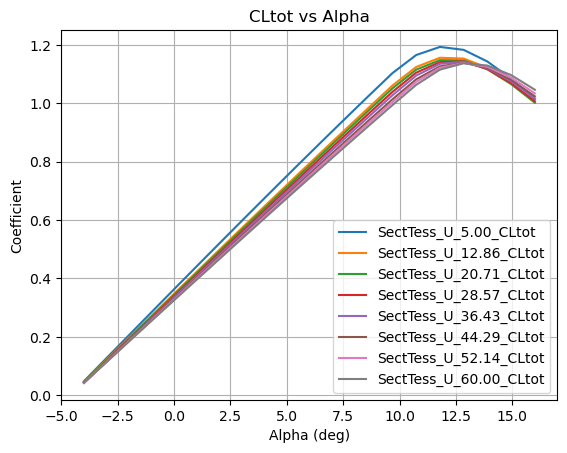

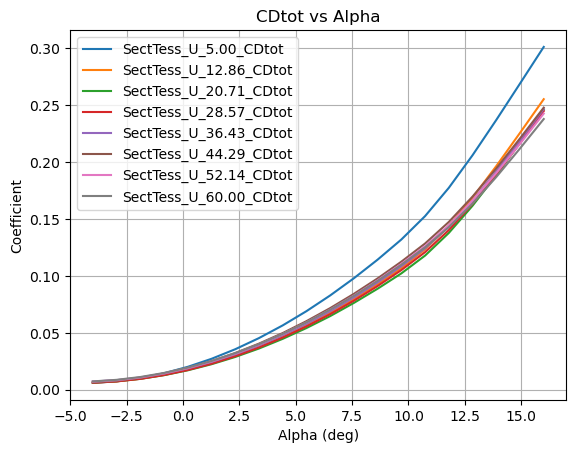

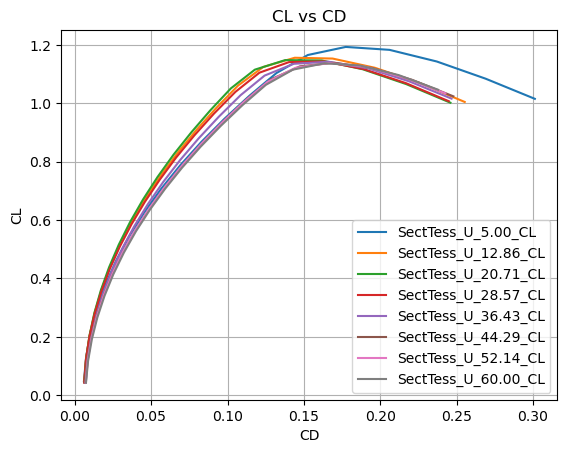

SectTess_U_5.00 max CL: 1.192845780165 at Alpha: 11.7895, lift slope 4.446048523311814
SectTess_U_12.86 max CL: 1.155753174128 at Alpha: 11.7895, lift slope 4.267150278760082
SectTess_U_20.71 max CL: 1.147702821301 at Alpha: 11.7895, lift slope 4.230088154763481
SectTess_U_28.57 max CL: 1.143293488365 at Alpha: 12.8421, lift slope 4.1883007001313866
SectTess_U_36.43 max CL: 1.142196580502 at Alpha: 12.8421, lift slope 4.142925995923886
SectTess_U_44.29 max CL: 1.138511860228 at Alpha: 12.8421, lift slope 4.087962692610598
SectTess_U_52.14 max CL: 1.137938579354 at Alpha: 12.8421, lift slope 4.0477681030235235
SectTess_U_60.00 max CL: 1.136980097394 at Alpha: 12.8421, lift slope 4.001739601943426


In [9]:
alphas = data_t1['Alpha']

for plot_label in to_get[1:]:
    for k,v in data_t2_span.items():
        for label, data_t2 in v.items():
            if plot_label == label:
                plt.plot(alphas, data_t2, label=f"{k}_{label}")
    plt.xlabel("Alpha (deg)")
    plt.ylabel("Coefficient")
    plt.title(f"{plot_label} vs Alpha")
    plt.legend()
    plt.grid()
    plt.show()


for k, v in data_t2_span.items():
    plt.plot(v['CDtot'], v['CLtot'], label=f"{k}_CL")
plt.xlabel("CD")
plt.ylabel("CL")
plt.title(f"CL vs CD")
plt.legend()
plt.grid()
plt.show()

for k, v in data_t2_span.items():
    print(f"{k} max CL: {get_max_cl(v)} at Alpha: {get_alpha_at_max_cl(v)}, lift slope {get_lift_slope(v)}")

Looks like the mesh size does not change the things significantly, but let's quantify that statement

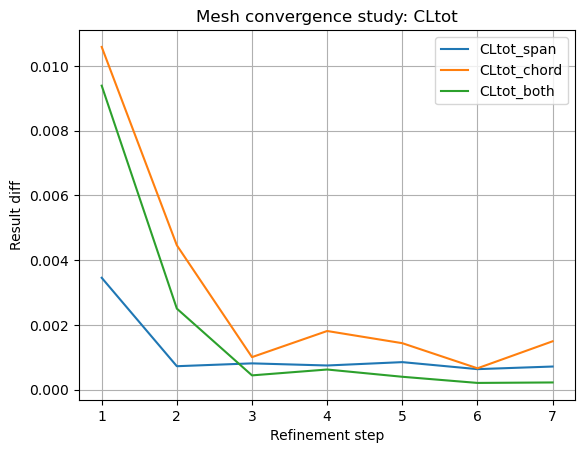

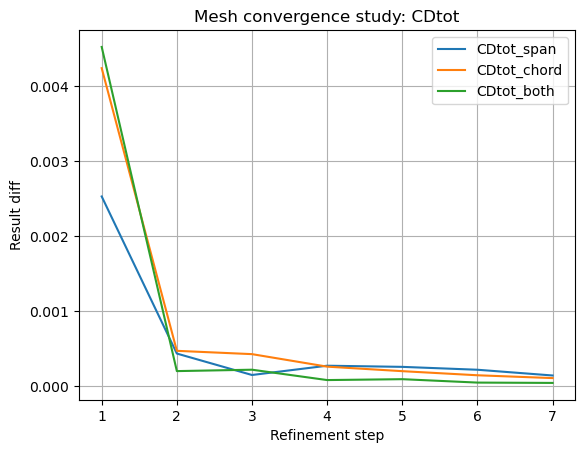

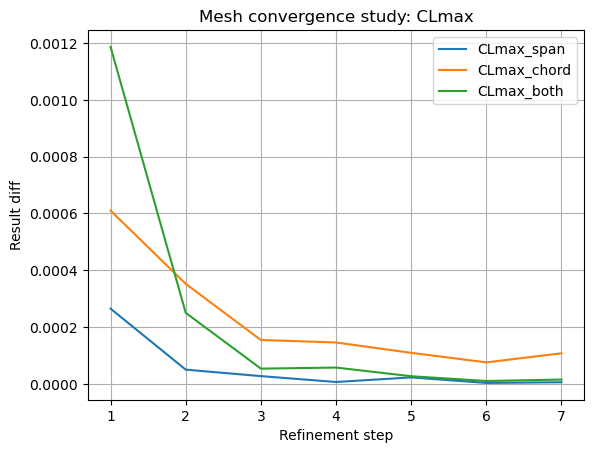

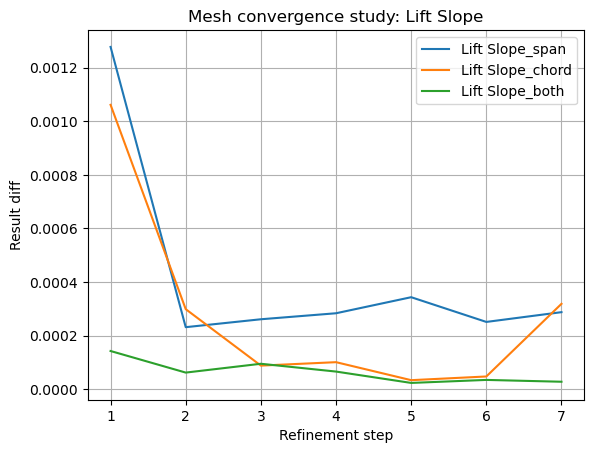

In [10]:
import numpy as np

n_panel_span = DEFAULT_W * np.linspace(chordwise_as.start, chordwise_as.end, N_POINTS, dtype=int)
n_panel_chord = DEFAULT_U * np.linspace(spanwise_as.start, spanwise_as.end, N_POINTS, dtype=int)
n_panel_both = np.linspace(chordwise_as.start, chordwise_as.end, N_POINTS, dtype=int) * np.linspace(spanwise_as.start, spanwise_as.end, N_POINTS, dtype=int)

for data_set in [data_t2_span, data_t2_chord, data_t2_both]:
    for exp_name, exp_value in data_set.items():
        exp_value['CLmax'] = [get_max_cl(exp_value)]
        exp_value['Lift Slope'] = [get_lift_slope(exp_value)]

for graph in to_get[1:] + ['CLmax', 'Lift Slope']:
    for label, data, counts in zip(['span', 'chord', 'both'], [data_t2_span, data_t2_chord, data_t2_both], [n_panel_span, n_panel_chord, n_panel_both]):
        data_diff = np.sum(np.abs(np.diff([v[graph] for k, v in data.items()], axis=0)), axis=1)
        plt.plot(range(1, N_POINTS), data_diff / np.diff(counts), label=f"{graph}_{label}")

    plt.xlabel("Refinement step")
    plt.ylabel("Result diff")
    plt.title(f"Mesh convergence study: {graph}")
    plt.legend()
    plt.grid()
    plt.show()


The refinement step 3 will be chosen for both span- and chord-wise panel counts, which amounts to 28 panels each (with rounding)

It could be seen that after the 3rd step the change in result is small, and the only significant change is really the post-stall behavior, for which panel codes are not really known to be accurate anyway.

The change in results is calculated as an L1 norm of the difference between the current and previous step, normalized by the change in panel count, which gives us a measure of how much we gain by adding more panels.

In [11]:
CHOSEN_STEP = 3
CHOSEN_U = int(np.linspace(spanwise_as.start, spanwise_as.end, N_POINTS, dtype=int)[CHOSEN_STEP])
CHOSEN_W = int(np.linspace(chordwise_as.start, chordwise_as.end, N_POINTS, dtype=int)[CHOSEN_STEP])

## Task 3

Here I found something interesting, the `ExportFile` does not respect the values set in `GeomSet` and `ThinGeomSet` and instead overrides them with values provided to the function itself. This requires a special treatment in the `vsp_manager` code and tracking of thin and thick settings manually as fields of the manager class.

Those values are later fed into the `ExportFile` function, which is responsible for exporting the geometry for the VSPAERO analysis.

The thin method is twice as fast, but the thick method is more accurate, with a lift slope closer to the theoretical value. The theoretical $C_{L,\alpha}$ could be found as $$C_{L,\alpha} = C_{l,\alpha} \frac{AR}{\frac{C_{l,\alpha}}{\pi} + \sqrt{(\frac{C_{l,\alpha}}{\pi})^2 + AR^2}}$$ which for a wing with 5 AR is equal to 4.169, while the thin and thick methods give 3.95 and 4.23 respectively.

Unfortunately I did not find any experimental data for this particular combination of airfoil, aspect ratio and Reynolds number to validate the case further.

In [12]:
# That should set Thin set, but it's already set
# Values are pulled out of diff-ing the vsp3 file while playing with this setting
from contexttimer import Timer
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="SectTess_U"), 20)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="Tess_W"), 20)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=thin_set_analysis, name="GeomSet"), 0)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=thin_set_analysis, name="ThinGeomSet"), -1)
vsp.Update()

with Timer() as timer:
    data_t3_thick = manager.perform_analysis(analysis_name, to_get)

print(f"Thick method execution time: {timer.elapsed:.2f}")

manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=thin_set_analysis, name="GeomSet"), -1)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=thin_set_analysis, name="ThinGeomSet"), 0)
vsp.Update()
vsp.Update()
vsp.UpdateGeom("WingGeom")

with Timer() as timer:
    data_t3_thin = manager.perform_analysis(analysis_name, to_get)


AR = 5
CL_alpha_theoretical = EXP_LIFT_SLOPE * AR / (EXP_LIFT_SLOPE / math.pi + math.sqrt((EXP_LIFT_SLOPE / math.pi) ** 2 + AR ** 2))

print(f"Experimental max 2D Cl: {MAX_2D_CL} at Alpha: {EXP_STALL_AOA}")
print(f"Experimental lift slope: {EXP_LIFT_SLOPE}")
print(f"Thin method execution time: {timer.elapsed:.2f}")
print(f"Thick method max CL: {get_max_cl(data_t3_thick)} at Alpha: {get_alpha_at_max_cl(data_t3_thick)}, lift slope {get_lift_slope(data_t3_thick)}")
print(f"Thin method max CL: {get_max_cl(data_t3_thin)} at Alpha: {get_alpha_at_max_cl(data_t3_thin)}, lift slope {get_lift_slope(data_t3_thin)}")
print(f"Theoretical lift slope: {CL_alpha_theoretical}")

Thick method execution time: 20.46
Experimental max 2D Cl: 1.41 at Alpha: 10
Experimental lift slope: 6.0876765733
Thin method execution time: 10.30
Thick method max CL: 1.148689240407 at Alpha: 11.7895, lift slope 4.234952209054541
Thin method max CL: 1.246898227391 at Alpha: 16.0, lift slope 3.95891469518083
Theoretical lift slope: 4.169566527394024


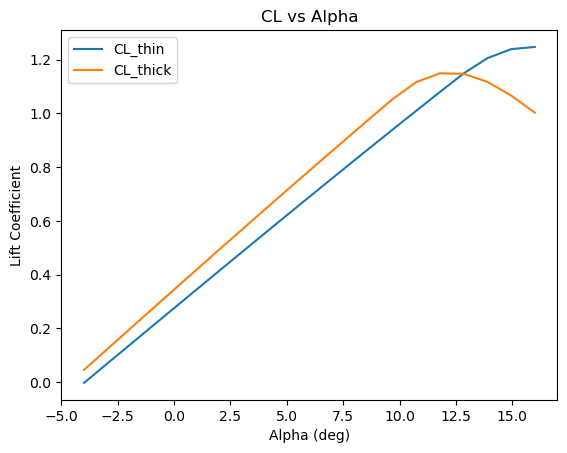

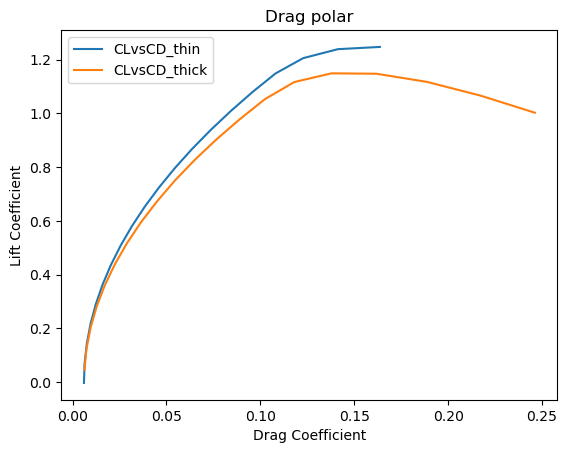

In [13]:
draw_polars([data_t3_thin, data_t3_thick], ['thin', 'thick'])

## Task 4
Let's bump the wingspan to 9600mm to increase the AR to 8, and see what happens

The $C_{L,\alpha}$ will be calculated with a simple finite difference from the linear region, and the theoretical $C_{L,\alpha}$ could be found again as $$C_{L,\alpha} = C_{l,\alpha} \frac{AR}{\frac{C_{l,\alpha}}{\pi} + \sqrt{(\frac{C_{l,\alpha}}{\pi})^2 + AR^2}}$$

Where the $C_{l,\alpha}$ could be found from the NACA report 824

The resulting theoretical lift slope is equal to 4.78, while the one obtained from the thick simulation is 4.85, a pretty good match

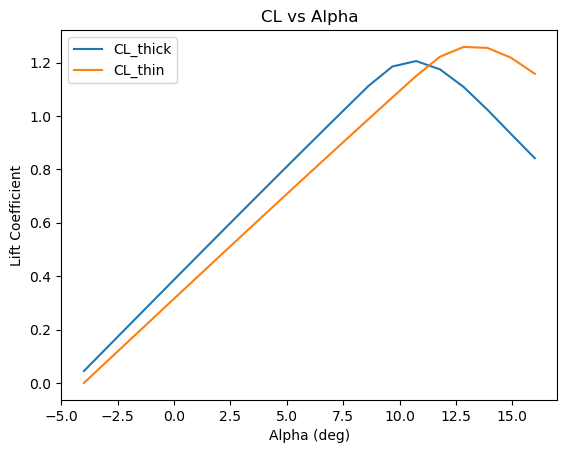

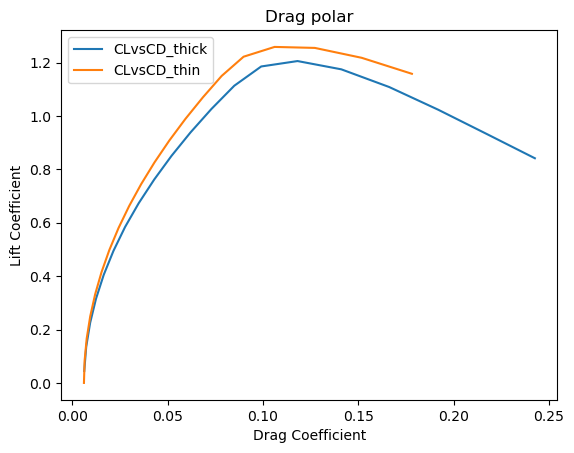

AR=8 thin wing max CL: 1.258566107967 at Alpha: 12.8421, lift slope 4.493862589930938
AR=8 thick wing max CL: 1.205628876534 at Alpha: 10.7368, lift slope 4.856341481296171


In [14]:


manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="TotalProjectedSpan"), 9600)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="TotalSpan"), 9600)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="SectTess_U"), CHOSEN_U)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=analysis_name, name="Tess_W"), CHOSEN_W)


manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=thin_set_analysis, name="GeomSet"), 0)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=thin_set_analysis, name="ThinGeomSet"), -1)
ar8_thick = manager.perform_analysis(analysis_name, to_get)

manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=thin_set_analysis, name="GeomSet"), -1)
manager.set_simulation_setting(AnalysisSettings(geom="WingGeom", analysis=thin_set_analysis, name="ThinGeomSet"), 0)
ar8_thin = manager.perform_analysis(analysis_name, to_get)

draw_polars([ar8_thick, ar8_thin], ['thick', 'thin'])
print(f"AR=8 thin wing max CL: {get_max_cl(ar8_thin)} at Alpha: {get_alpha_at_max_cl(ar8_thin)}, lift slope {get_lift_slope(ar8_thin)}")
print(f"AR=8 thick wing max CL: {get_max_cl(ar8_thick)} at Alpha: {get_alpha_at_max_cl(ar8_thick)}, lift slope {get_lift_slope(ar8_thick)}")

In [15]:
AR = 8
CL_alpha_theoretical = EXP_LIFT_SLOPE * AR / (EXP_LIFT_SLOPE / math.pi + math.sqrt((EXP_LIFT_SLOPE / math.pi) ** 2 + AR ** 2))
CL_alpha_theoretical

4.789153446267931

## Conclusion
* VSPAERO could be used to analyze the wing geometry and obtain the lift and drag characteristics, both as a GUI app and using the Python API. The calculation is relatively cheap in terms of computational resources, and it gives reasonable results for the lift slope and maximum lift coefficient.
* The VSPAERO API documentation and documentation in general is lacking, hence, the main source of information about is their Google group, snippets of code from various developers and the Monte-Carlo method of changing things and observing the result.
* The mesh refinement study showed that after a certain point, increasing the number of panels does not significantly change the results, indicating that we have reached a good balance between accuracy and computational cost.
* The comparison between thin and thick methods revealed that while the thin method is faster, it is not as accurate as the thick method for both cases (AR=5 and AR=8).

## Used resources
* NACA report 824: https://ntrs.nasa.gov/api/citations/19930090976/downloads/19930090976.pdf
* VSPAERO: https://openvsp.org/
* VSPAERO API documentation: https://openvsp.org/api_docs/latest/
* VSPAERO validation studies: https://github.com/JARC99/vspaero-validation-studies
* VSPAERO examples: https://github.com/OpenVSP/OpenVSP/tree/main/examples

## Code
Could be found in my repository: https://github.com/UavYuriyS/ad_assignments
* Follow the readme for the replication instructions, but in essence, you need to have OpenVSP installed and python bindings built and then run the notebook with the correct path to the OpenVSP installation and the `wing_assignment.vsp3` file.
